In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

In [2]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


In [3]:
print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


In [4]:
print('\nUnique labels in training set:', np.unique(y_train))


Unique labels in training set: [0 1 2 3 4 5 6 7 8 9]


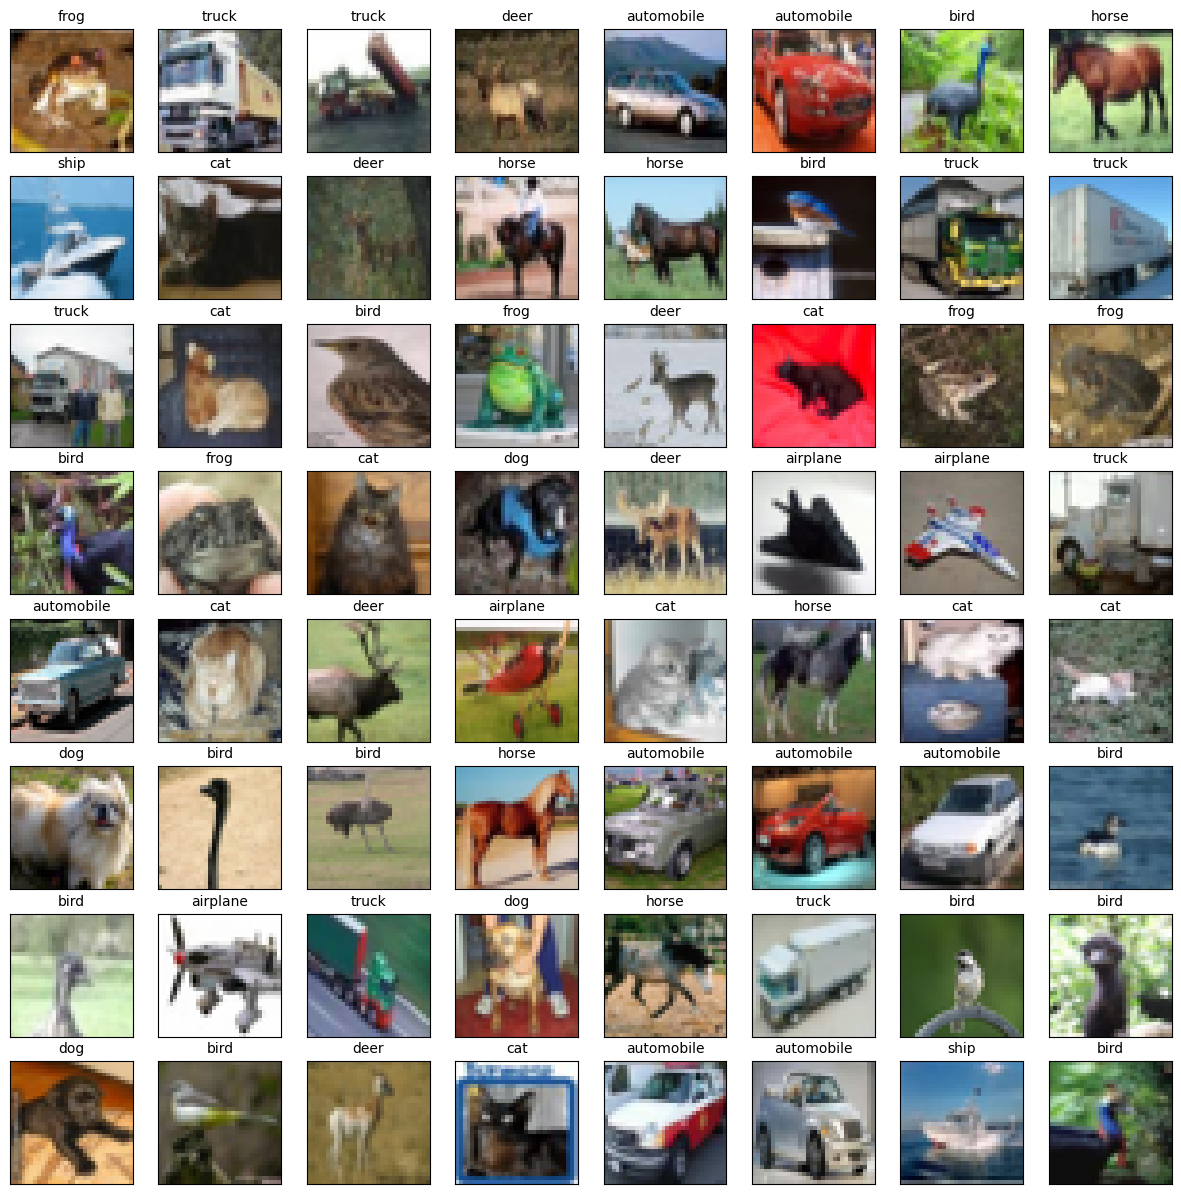

In [5]:

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
               
plt.figure(figsize=(15,15))

for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]], fontsize=10)

plt.show()

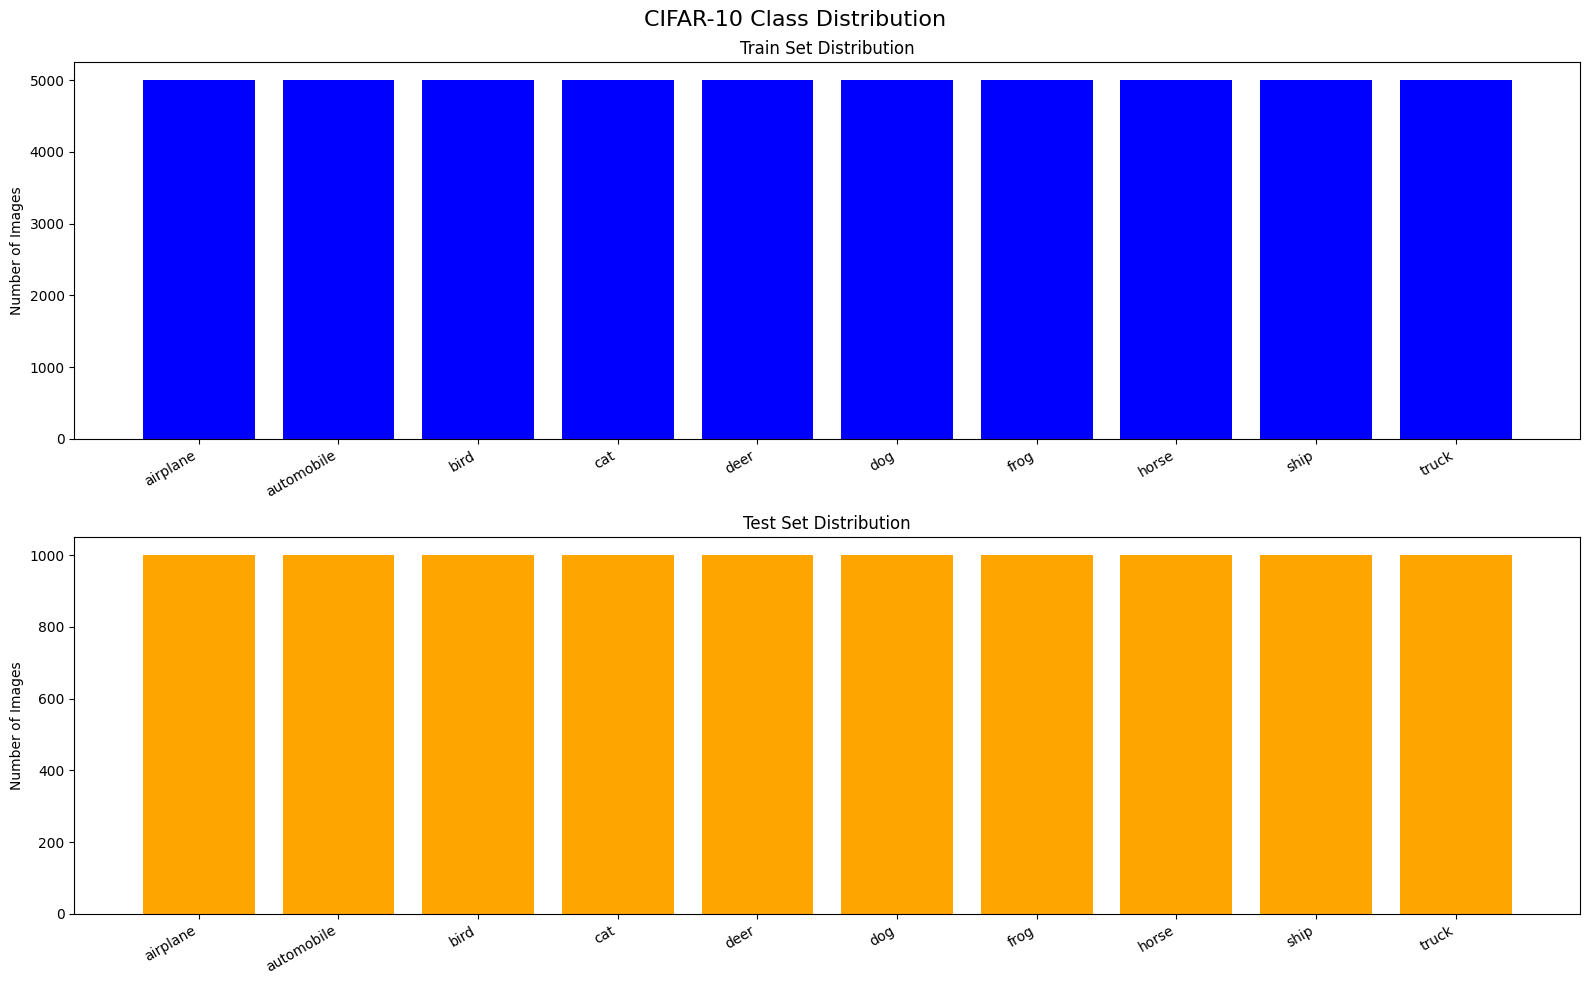

In [6]:
train_counts = np.bincount(y_train.flatten(), minlength=len(class_names))
test_counts = np.bincount(y_test.flatten(), minlength=len(class_names))

x = np.arange(len(class_names))

plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
plt.bar(x, train_counts, color='blue')
plt.title('Train Set Distribution')
plt.xticks(x, class_names, rotation=30, ha='right')
plt.ylabel('Number of Images')

plt.subplot(2, 1, 2)
plt.bar(x, test_counts, color='orange')
plt.title('Test Set Distribution')
plt.xticks(x, class_names, rotation=30, ha='right')
plt.ylabel('Number of Images')

plt.suptitle('CIFAR-10 Class Distribution', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# Standardize the values between -1 to 1 for better performance of the model

x_train_min = np.min(x_train)
x_train_max = np.max(x_train)
x_train_normalized = (x_train - x_train_min) / (x_train_max - x_train_min)
x_test_normalized = (x_test - x_train_min) / (x_train_max - x_train_min)


x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)
x_train_standardized = (x_train - x_train_mean) / x_train_std

In [8]:
# Convert to Grayscale
x_train_gray = np.mean(x_train_normalized, axis=3)
x_test_gray = np.mean(x_test_normalized, axis=3)

print("Grayscale Training set shape:", x_train_gray.shape)
print("Grayscale Test set shape:", x_test_gray.shape)

Grayscale Training set shape: (50000, 32, 32)
Grayscale Test set shape: (10000, 32, 32)


In [9]:
# Flatten Raw Pixels
x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1)
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1)

print("Flattened Training set shape:", x_train_flat.shape)
print("Flattened Test set shape:", x_test_flat.shape)

Flattened Training set shape: (50000, 1024)
Flattened Test set shape: (10000, 1024)


In [10]:
# Standardize the flattened pixel values
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

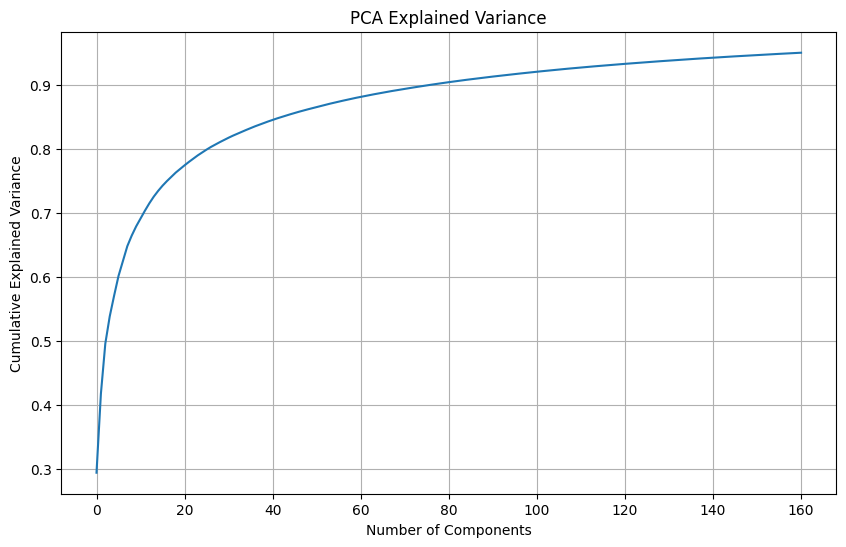

Components selected: 161


In [11]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [12]:
#KNN Without PCA
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_scaled, y_train.reshape(-1,))
y_KNN = KNN.predict(x_test_scaled)
print("KNN without PCA Accuracy:", accuracy_score(y_test, y_KNN))

KNN without PCA Accuracy: 0.3015


In [13]:
#KNN with PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca,y_train.reshape(-1,))
y_KNN_pca = KNN_pca.predict(x_test_pca)
print("KNN with PCA Accuracy:", accuracy_score(y_test, y_KNN_pca))

KNN with PCA Accuracy: 0.3251


In [14]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_scaled, y_train.reshape(-1,))
y_ModelNaive = ModelNaive.predict(x_test_scaled)
print("Naive Bayes without PCA Accuracy:", accuracy_score(y_test, y_ModelNaive))

Naive Bayes without PCA Accuracy: 0.268


In [15]:
# Naive Bayes with PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train.reshape(-1,))
y_ModelNaive_pca = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA Accuracy:", accuracy_score(y_test, y_ModelNaive_pca))

Naive Bayes with PCA Accuracy: 0.2676


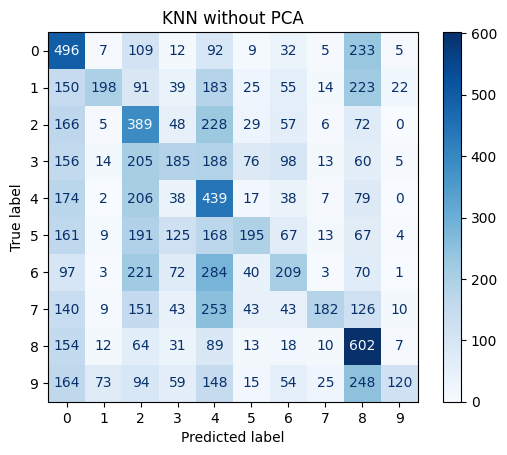

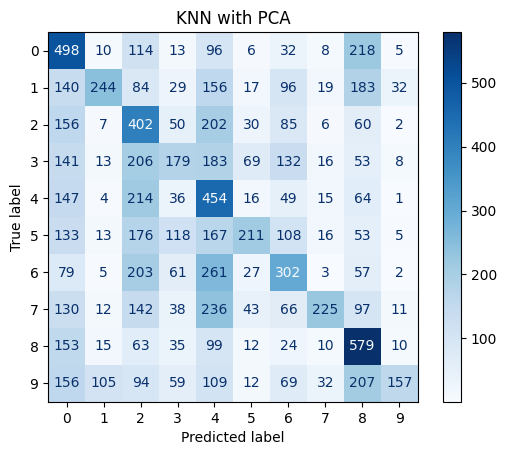

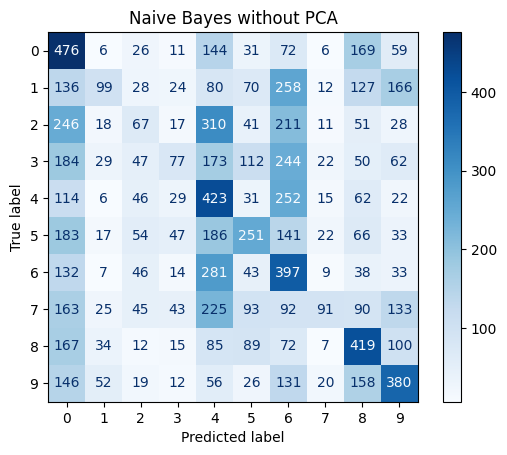

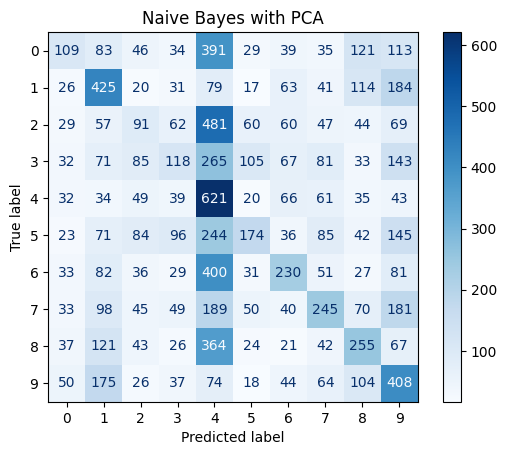

In [26]:
#Confusion Matrix
def confusion(y, y_pred , title):
    z= confusion_matrix(y, y_pred)
    d= ConfusionMatrixDisplay(confusion_matrix=z)
    d.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

confusion(y_test, y_KNN, "KNN without PCA")
confusion(y_test, y_KNN_pca, "KNN with PCA")

confusion(y_test, y_ModelNaive, "Naive Bayes without PCA")
confusion(y_test, y_ModelNaive_pca, "Naive Bayes with PCA")